In [2]:
import os
import json
import pdb
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Time series
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit

# SARIMAX 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import LSTM
from tensorflow.keras.optimizers import Adam
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler


# Jump Diffusion 
from sklearn.preprocessing import StandardScaler

# Process Track 
from tqdm import tqdm


# Utilities 

In [138]:
def get_online_quantile(scores, q_1, etas, alpha):
    """
    Computes the online quantile of a set of scores.
    :param scores: (np.array) The scores.
    :param q_1: (float) The quantile to compute.
    :param eta: (np.array) The sequence of learning rates.
    :return: (float) The sequence of online quantiles.
    """
    T = scores.shape[0]
    q = np.zeros(T)
    q[0] = q_1
    for t in range(T):
        err_t = (scores[t] > q[t]).astype(int)
        if t < T - 1:
            q[t + 1] = q[t] - etas[t] * (alpha - err_t)
    return q


def compute_coverage_metrics(Y, Yhat, alpha, epsilon, W, C):
    """
    Compute online quantiles, observed coverages, long-run coverage (LRC), 
    rolling coverage, and time-conditional coverage.

    Parameters:
        scores (numpy array): Array of scores for the main dataset.
        scores_val (numpy array): Array of scores for the validation dataset.
        alpha (float): 1 - alpha is the desired coverage level.
        epsilon (float): Decay parameter for eta in the decaying quantile.
        W (int): Window size for rolling coverage computation.
        C: Constant of etas decaying 

    Returns:
        dict: Dictionary containing all computed metrics.
    """
    scores = np.abs(Y - Yhat)
    #scores_val = scores[::2]
    #scores = scores[1::2]
    T = len(scores)
    #N_val = len(scores_val)
    
    # Define learning rates
    #etas_fixed = np.ones(T) * fixed_step_size
    etas_decaying = C * (np.array([1 / (t ** (1 / 2 + epsilon)) for t in range(1, T + 1)]))

    # Compute the oracle quantile
    #q_star = np.quantile(scores, 1 - alpha)
    
    # Initialize first quantile value
    q_1 = scores[0]

    # Compute online quantiles
    #q_fixed = get_online_quantile(scores, q_1, etas_fixed, alpha)
    q_decaying = get_online_quantile(scores, q_1, etas_decaying, alpha)

    # Compute observed coverage
    #observed_coverages_fixed = (scores <= q_fixed).astype(int)
    observed_coverages_decaying = (scores <= q_decaying).astype(int)
    #observed_coverages_oracle = (scores <= q_star).astype(int)

    # Compute long-run coverage
    #LRC_fixed = np.cumsum(observed_coverages_fixed) / (np.arange(len(observed_coverages_fixed)) + 1)
    LRC_decaying = np.cumsum(observed_coverages_decaying) / (np.arange(len(observed_coverages_decaying)) + 1)
    #LRC_qstar = np.cumsum(observed_coverages_oracle) / (np.arange(len(observed_coverages_oracle)) + 1)

    # Compute rolling coverage
    #rolling_coverage_fixed = smooth_array(observed_coverages_fixed, W)
    #rolling_coverage_decaying = smooth_array(observed_coverages_decaying, W)
    #rolling_coverage_oracle = smooth_array(observed_coverages_oracle, W)

    # Compute time-conditional coverage
    #time_coverage_fixed = (scores_val[:,None] <= q_fixed[None,:]).mean(axis=0)
    #time_coverage_decaying = (scores_val[:,None] <= q_decaying[None,:]).mean(axis=0)
    #time_coverage_qstar = (scores_val[:,None] <= q_star*np.ones_like(q_decaying)[None,:]).mean(axis=0)

    return {
        "T":T,
        #"q_fixed": q_fixed,
        "q_decaying": q_decaying,
        #"q_star": q_star,
        #"observed_coverages_fixed": observed_coverages_fixed,
        "observed_coverages_decaying": observed_coverages_decaying,
        #"observed_coverages_oracle": observed_coverages_oracle,
        #"LRC_fixed": LRC_fixed,
        "LRC_decaying": LRC_decaying,
        #"LRC_qstar": LRC_qstar,
        #"rolling_coverage_fixed": rolling_coverage_fixed,
        #"rolling_coverage_decaying": rolling_coverage_decaying,
        #"rolling_coverage_oracle": rolling_coverage_oracle,
        #"time_coverage_fixed": time_coverage_fixed,
        #"time_coverage_decaying": time_coverage_decaying,
        #"time_coverage_qstar": time_coverage_qstar
    }

def plot_coverage_results(results, alpha, W):
    """
    Plots the quantile evolution, long-run coverage
    for a single dataset using results from compute_coverage_metrics.

    Parameters:
        results (dict): Dictionary output from compute_coverage_metrics.
        alpha (float): 1 - alpha is the desired coverage level.
        W (int): Window size for rolling coverage computation.

    Returns:
        None (Displays the plot).
    """

    T = results['T']

    sns.set_style("white")
    sns.set_palette("Set2")

    # ---- Plot 1: Quantiles ----
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["q_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    #plt.plot(range(T), results["q_star"] * np.ones_like(results["q_decaying"]), label=r'$q^*$')
    plt.ylabel(r'$q_t$')
    plt.xlabel(r'time $t$')
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

    # ---- Plot 2: Long-run coverage ----
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["LRC_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    #plt.plot(range(T), results['LRC_qstar'], label=r'$q^*$')
    plt.axhline(y=1 - alpha, linestyle='dotted', color="k", linewidth=2, label=r'$1-\alpha$')
    plt.xlabel(r'time $t$')
    plt.ylabel("long-run coverage")
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()



def causal_ma(y, w):
    s = pd.Series(np.asarray(y, dtype=float))
    return s.rolling(window=w, min_periods=w).mean().shift(1).to_numpy()


# SARIMAX

def rolling_sarimax_forecast_recursive(data, train_size, p, d, q):
    """
    Perform rolling h-step recursive forecasting using SARIMAX.

    Parameters:
        data (pd.Series): Time series data.
        train_size (int): Initial training points.
        p, d, q (int): SARIMAX order.
        h (int): Forecast horizon (align with LSTM seq_length).

    Returns:
        np.array: Sequence of h-step-ahead predictions.
    """
    rolling_predictions = []
    train_data = data.iloc[:train_size].copy()

    sarimax_model = SARIMAX(train_data, order=(p, d, q),
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit(disp=False)

    for t in tqdm(range(len(data) - train_size -4)):
        # make h recursive forecasts
        model_copy = sarimax_model 
        preds = []
        for step in range(5):
            next_pred = model_copy.forecast(steps=1).values[0]
            preds.append(next_pred)
            # feed prediction back instead of true obs
            model_copy = model_copy.append([next_pred], refit=False)

        # save the h-step-ahead prediction (align with horizon h)
        rolling_predictions.append(preds[-1])

        # update main model with the true next observation
        true_obs = data.iloc[train_size + t]
        sarimax_model = sarimax_model.append([true_obs], refit=False)

    return np.array(rolling_predictions)


from sklearn.metrics import mean_squared_error
import itertools
import numpy as np
import pandas as pd

def sarimax_grid_search(observed_data, y_true_test, train_size,
                        p_values, d_values, q_values,
                        verbose=True, return_table=False):
    """
    Grid search for SARIMAX using your rolling_sarimax_forecast().

    Parameters
    ----------
    observed_data : pd.Series or array-like
        Full observed series used to fit/append (length = n).
    y_true_test : pd.Series or array-like
        Ground-truth targets for t = train_size ... n-1
        (length should be n - train_size).
    train_size : int
        Initial training size used inside rolling_sarimax_forecast.
    p_values, d_values, q_values : list[int]
        Candidate SARIMAX orders.
    verbose : bool
        Print progress.
    return_table : bool
        If True, also return a DataFrame of all configs and RMSE.

    Returns
    -------
    best_cfg : tuple (p, d, q)
    best_score : float (RMSE)
    results_df : pd.DataFrame (optional)
    """
    # Coerce to proper dtypes
    if not isinstance(observed_data, pd.Series):
        observed_data = pd.Series(np.asarray(observed_data))
    y_true_test = np.asarray(y_true_test).astype(float)

    n = len(observed_data)
    expected_len = n - train_size
    if expected_len <= 0:
        raise ValueError(f"train_size={train_size} leaves no test points (n={n}).")

    # If user-provided y_true_test length differs, we'll align by truncation
    if len(y_true_test) != expected_len and verbose:
        print(f"⚠️  y_true_test length ({len(y_true_test)}) "
              f"!= expected ({expected_len}). Will align by min length.")
    results = []

    best_score, best_cfg = np.inf, None

    for p, d, q in itertools.product(p_values, d_values, q_values):
        try:
            preds = rolling_sarimax_forecast_recursive(observed_data, train_size, p, d, q)
            preds = np.asarray(preds).astype(float)

            # Check/align lengths
            m = min(len(preds), len(y_true_test))
            if m == 0:
                if verbose:
                    print(f"⏭️  Skipping SARIMAX({p},{d},{q}) — zero-length alignment.")
                continue

            y_true = y_true_test[-m:]
            y_pred = preds[-m:]

            rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
            results.append({"p": p, "d": d, "q": q, "rmse": rmse})

            if verbose:
                print(f"SARIMAX({p},{d},{q}) RMSE={rmse:.4f}")

            if rmse < best_score:
                best_score, best_cfg = rmse, (p, d, q)

        except Exception as e:
            if verbose:
                print(f"SARIMAX({p},{d},{q}) failed: {e}")
            continue

    if not results:
        raise RuntimeError("All configurations failed or produced empty predictions.")

    if verbose:
        print(f"✅ Best SARIMAX{best_cfg} RMSE={best_score:.4f}")

    if return_table:
        return best_cfg, best_score, pd.DataFrame(results).sort_values("rmse")
    return best_cfg, best_score

def create_sequences(data, seq_length, train_ratio=0.8):
    data = np.array(data)  # ensure numpy
    data_len = len(data)
    train_size = int(data_len * train_ratio)

    train_data = data[:train_size]
    test_data  = data[train_size:]  # strict split

    # Training sequences
    X_train, y_train = [], []
    for i in range(len(train_data) - seq_length):
        X_train.append(train_data[i:i+seq_length])
        y_train.append(train_data[i+seq_length])

    # Testing sequences
    X_test, y_test = [], []
    for i in range(len(test_data) - seq_length):
        X_test.append(test_data[i:i+seq_length])
        y_test.append(test_data[i+seq_length])

    # Reshape for LSTM [samples, timesteps, features]
    X_train = np.array(X_train).reshape(-1, seq_length, 1)
    y_train = np.array(y_train)
    X_test  = np.array(X_test).reshape(-1, seq_length, 1)
    y_test  = np.array(y_test)

    return X_train, X_test, y_train, y_test


# COMA 


def hedge(loss_matrix, eta):
    """
    Hedge algorithm.

    Parameters
    ----------
    loss_matrix : np.ndarray
        Shape (N, K), loss of K experts during N rounds.
    eta : float
        Learning rate parameter.

    Returns
    -------
    dict
        h : np.ndarray of shape (N,)
            Weighted average loss at each round.
        weights : np.ndarray of shape (N, K)
            Expert weights at each round.
    """
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)          # vector of length N
    weights = np.full((N, K), np.nan)  # N x K matrix
    w = np.full(K, 1.0 / K)         # start uniform weights

    for t in range(N):
        weights[t, :] = w
        w = w * np.exp(-eta * loss_matrix[t, :])  # exponential weighting
        w = w / np.sum(w)                         # normalize
        h[t] = np.sum(w * loss_matrix[t, :])      # weighted average loss

    return {"h": h, "weights": weights}


def counts_int(M, a, b, w):
    """
    Compute weighted fraction of intervals in M that cover the midpoint of [a,b].
    
    Parameters
    ----------
    M : np.ndarray
        Shape (n, 2), intervals with lower and upper bounds.
    a, b : float
        Interval boundaries.
    w : np.ndarray
        Weights for each interval (length n).
    
    Returns
    -------
    float
        Weighted mean (between 0 and 1).
    """
    mid = 0.5 * (a + b)
    inside = (M[:, 0] <= mid) & (mid <= M[:, 1]) 
    inside = inside.astype(float)                  
    num_int = np.average(inside, weights=w)
    return num_int


def mix(L, eta):
    """
    Python translation of R mix().
    """
    mn = np.min(L)

    if np.isinf(eta):
        w = (L == mn).astype(float)
        w /= w.sum()
    else:
        w = np.exp(-eta * (L - mn))

    s = np.sum(w)
    w = w / s
    M = mn - (1.0 / eta) * np.log(s / len(L)) if not np.isinf(eta) else mn

    return {"w": w, "M": M}

def adahedge(loss_matrix):
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)
    L = np.zeros(K)
    etas = np.full(N, np.nan)
    weights = np.full((N, K), np.nan)
    Delta = 0.0

    for t in range(N):
        eta = np.log(K) / Delta if Delta > 0 else np.inf
        result = mix(L, eta=eta)
        w, Mprev = result["w"], result["M"]

        h[t] = np.dot(w, loss_matrix[t])
        weights[t] = w
        L = L + loss_matrix[t]

        result = mix(L, eta=eta)
        delta = max(0.0, h[t] - (result["M"] - Mprev))
        Delta += delta
        etas[t] = eta

    return {"h": h, "weights": weights, "eta": etas}



def majority_vote(M, w, rho):
    breaks = np.unique(M.flatten())
    breaks.sort()

    lower, upper = [], []

    if np.mean(np.isinf(M[:, 1])) > rho:
        return np.array([[-np.inf, np.inf]])

    i = 0
    while i < len(breaks) - 1:
        cond = counts_int(M, breaks[i], breaks[i+1], w) > rho
        if cond:
            lower.append(breaks[i])
            j = i
            while j < len(breaks) - 1 and cond:
                j += 1
                if j < len(breaks) - 1:   
                    cond = counts_int(M, breaks[j], breaks[j+1], w) > rho
                else:
                    cond = False
            upper.append(breaks[j])
            i = j
        i += 1

    if not lower:
        return np.nan
    else:
        return np.column_stack([lower, upper])


def covr_fun(ci, target):
    """
    Coverage function: check if target lies inside interval(s).
    
    ci: np.ndarray (L, 2) or (2,), interval(s)
    target: float, true value
    
    Returns: 1 if covered, 0 otherwise
    """
    if isinstance(ci, float) and np.isnan(ci):
        return 0

    ci = np.atleast_2d(ci)
    covr = 0
    for l, u in ci:
        covr += int((l <= target) and (target <= u))
    return covr

import numpy as np

def loss_fun(ci):
    """
    Compute the width of confidence interval(s).
    
    Parameters
    ----------
    ci : np.ndarray or list
         - shape (2,)   → single interval [low, high]
         - shape (L, 2) → multiple intervals
         - np.nan       → no interval
    
    Returns
    -------
    float
        total width (sum of all intervals' widths)
    """

    if ci is None or (isinstance(ci, float) and np.isnan(ci)):
        return 0.0
    ci = np.atleast_2d(ci)
    
    width = 0.0
    for l, u in ci:
        if np.isnan(l) or np.isnan(u):
            continue
        width += (u - l)
    return width

import numpy as np

def coma_loop(intervals_list, weights, data_y):
    """
    COMA aggregation loop (Python translation of the R code).
    
    intervals_list: list of arrays [N x 2], one for each expert's intervals
    weights: array [N x K], AdaHedge weights
    data_y: array of true outcomes
    """
    N, K = weights.shape
    pi_m, pi_wm = [], []
    m_cov, wm_cov = [], []

    for i in range(N):
        # stack intervals from all experts for round i
        conf_t = np.vstack([intervals[i] for intervals in intervals_list])

        # deterministic majority vote (rho=0.5 for strict majority)
        maj_int = majority_vote(conf_t, w=weights[i], rho=0.5)

        # randomized majority vote (rho ∈ [0.5,1])
        rho_rand = np.random.uniform(0.5, 1.0)
        wmaj_int = majority_vote(conf_t, w=weights[i], rho=rho_rand)

        # store intervals
        pi_m.append(maj_int)
        pi_wm.append(wmaj_int)

        # coverage check (ensure index alignment!)
        target_idx = i
        if target_idx < len(data_y):
            m_cov.append(covr_fun(maj_int, data_y[target_idx]))
            wm_cov.append(covr_fun(wmaj_int, data_y[target_idx]))
        else:
            m_cov.append(0)
            wm_cov.append(0)

    return {
        "pi_m": pi_m,
        "pi_wm": pi_wm,
        "m_cov": np.array(m_cov),
        "wm_cov": np.array(wm_cov),
        "mean_m_cov": np.mean(m_cov),
        "mean_wm_cov": np.mean(wm_cov)
    }

In [ ]:
# GRU 

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam

# --- Build GRU model ---
def build_gru(seq_length=15, units1=128, units2=64, dropout=0.2, lr=0.001):
    model = Sequential([
        GRU(units1, activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
        Dropout(dropout),
        GRU(units2, activation='tanh'),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss=tf.keras.losses.Huber())
    return model

# --- Train GRU base learner ---
def train_gru(X_train, y_train, seq_length=15, units1=128, units2=64, dropout=0.2, lr=0.001, epochs=15, batch_size=16):
    gru_model = build_gru(seq_length, units1, units2, dropout, lr)
    history = gru_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                            verbose=0, validation_split=0.1, shuffle=False)
    return gru_model, history

# --- Predict with GRU ---
def predict_gru(gru_model, X_test):
    return gru_model.predict(X_test).flatten()

# Experiment

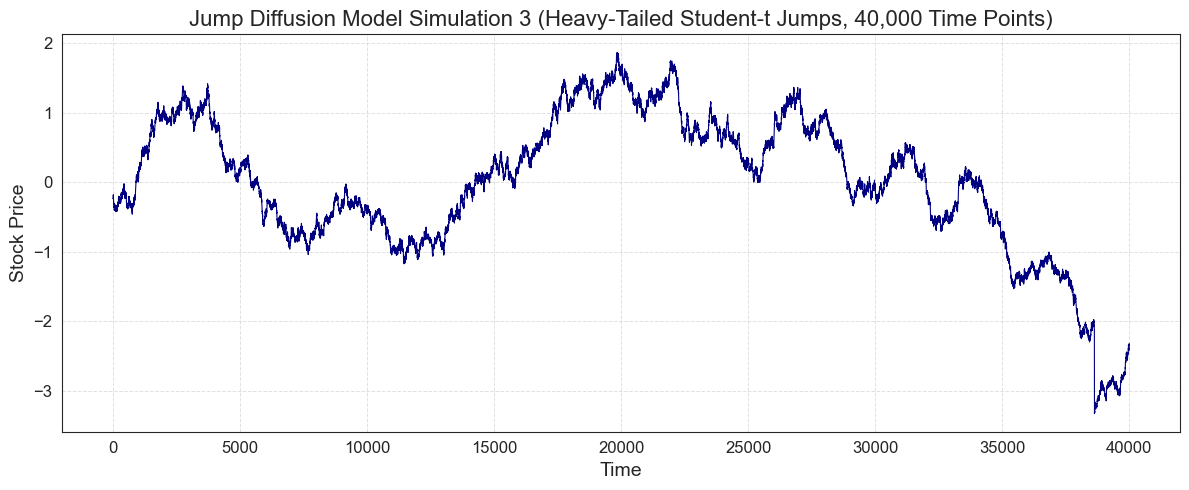

In [23]:
# Set seed for reproducibility
np.random.seed(42)

# Parameters
S0 = 100                # initial stock price
mu = 0.05               # drift
sigma = 0.2             # volatility
lamb = 0.5              # jump intensity
df_t = 2                # degrees of freedom for heavy-tailed t distribution
scale_t = 0.3           # scale parameter for t-distribution
T = 1.0                 # total time
N = 40000               # number of time steps
dt = T / N              # time step


# Time grid
t = np.arange(N)

# Brownian increments
dW = np.random.normal(0, np.sqrt(dt), N)
# Poisson jump component
N_jumps = np.random.poisson(lamb * dt, N)  # 0 or 1 jumps per step
J = np.random.standard_t(df_t, size=N) * scale_t   # heavy-tailed jump sizes (Student's t)
jump_component = (np.exp(J) - 1) * N_jumps

# Initialize price path
S = np.zeros(N)
S[0] = S0

# Simulate path
for i in range(1, N):
    S[i] = S[i-1] * (1 + mu * dt + sigma * dW[i] + jump_component[i])

scaler = StandardScaler()
S_sd = scaler.fit_transform(S.reshape(-1, 1)).flatten()


data_jd_sd = pd.DataFrame({'x': t, 'y': S_sd})
# y_observed = y + noise 
# y_true 

# Plot
plt.figure(figsize=(12, 5))

# Plot with publication style
plt.plot(data_jd_sd['x'], data_jd_sd['y'], color="navy", linewidth=0.8)

# Titles and labels
plt.title('Jump Diffusion Model Simulation 3 (Heavy-Tailed Student-t Jumps, 40,000 Time Points)', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Stock Price', fontsize=14)

# Grid & frame
plt.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=12)

# Clean frame
plt.tight_layout()
plt.show()

In [31]:
# Train-test split 
sigma_t = np.exp(-2 + 0.3 * np.random.normal(size=N))  # mean ≈ 0.14, clustering still present
noise = np.random.normal(0, sigma_t, size=N)
y_observed = data_jd_sd['y'] + noise 
train_size3 = int(0.8 * len(y_observed))
test_size = int(0.2 * len(y_observed))

y_train_sim3 = y_observed[:train_size3]
y_test_sim3 = y_observed[train_size3:]
y_true = data_jd_sd['y'].to_numpy()
y_true_test = data_jd_sd['y'].to_numpy()[train_size3:] 


print(f"Train dataset shape: {y_train_sim3.shape}, Test dataset shape: {y_test_sim3.shape}")



Train dataset shape: (32000,), Test dataset shape: (8000,)


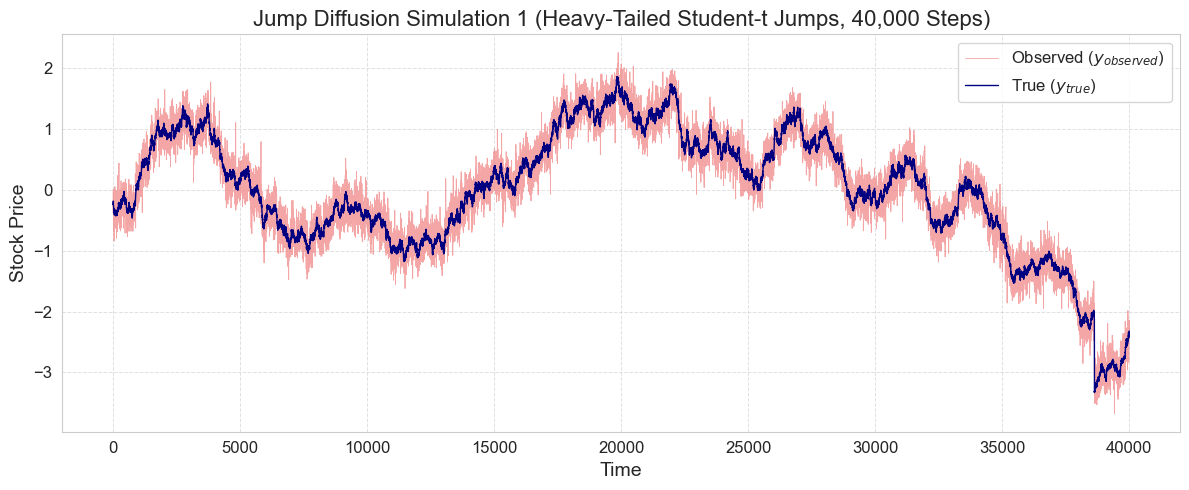

In [155]:
plt.figure(figsize=(12, 5))

# Plot observed series (noisy)
plt.plot(data_jd_sd['x'], y_observed, 
         color="lightcoral", linewidth=0.6, alpha=0.7, 
         label="Observed ($y_{observed}$)")

# Plot clean series (true trajectory)
plt.plot(data_jd_sd['x'], data_jd_sd['y'], 
         color="navy", linewidth=1.0, 
         label="True ($y_{true}$)")

# Titles and labels
plt.title('Jump Diffusion Simulation 1 (Heavy-Tailed Student-t Jumps, 40,000 Steps)', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Stock Price', fontsize=14)

# Grid, legend, and formatting
plt.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Base Learners

### GARCH 

  0%|          | 0/8000 [00:00<?, ?it/s]/Users/victoria/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0434. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
  0%|          | 1/8000 [00:00<46:19,  2.88it/s]/Users/victoria/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.04341. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting resc

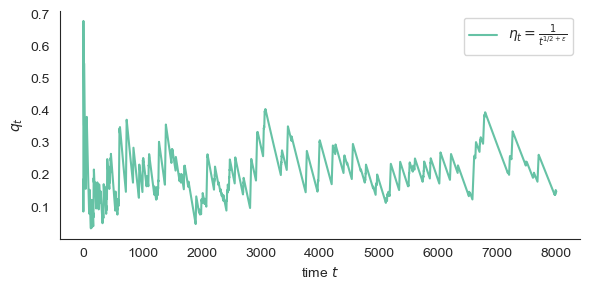

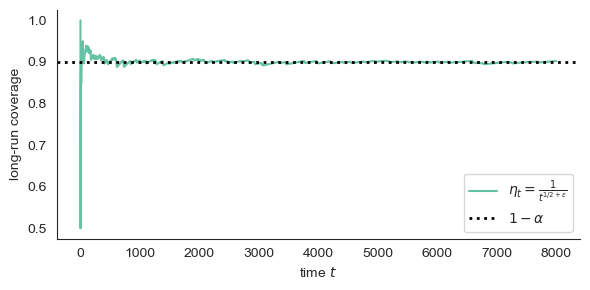

0.2173977629778571


In [126]:
from arch import arch_model
import numpy as np
from tqdm import tqdm


def garch_forecast(data, train_size, horizon=1, refit_every=50,
                   mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='t'):
    """
    Rolling GARCH forecast with optional AR mean and less frequent refits.

    Parameters:
        data (array-like): time series (e.g., returns).
        train_size (int): number of points in training set.
        horizon (int): forecast horizon (default = 1).
        refit_every (int): how often to refit the GARCH model (default=50).
        mean (str): mean model type ('Zero', 'Constant', 'AR').
        lags (int): number of AR lags if mean='AR'.
        vol (str): volatility model type ('GARCH', 'EGARCH', etc.).
        p, q (int): GARCH orders.
        dist (str): error distribution ('normal', 't', 'skewt', 'ged').

    Returns:
        np.array: mean forecasts for the test set.
    """
    data = np.asarray(data, dtype=float)
    train, test = data[:train_size], data[train_size:]
    
    preds = []
    res = None
    for t in tqdm(range(len(test))):
        if t % refit_every == 0 or res is None:
            train_subset = np.concatenate([train, test[:t]])
            model = arch_model(train_subset,
                               mean=mean, lags=lags,
                               vol=vol, p=p, q=q, dist=dist)
            res = model.fit(disp="off")
        
        forecast = res.forecast(horizon=horizon, reindex=False)
        pred = forecast.mean.iloc[-1, 0]
        preds.append(pred)
    
    return np.array(preds)

# --- Example usage ---
y = y_observed.to_numpy()
train_size = int(0.8 * len(y))

# Try GARCH(1,1) with AR(1) mean and Student-t errors
y_garch_pred = garch_forecast(
    y, train_size,
    mean='AR', lags=1,
    vol='GARCH', p=1, q=1,
    dist='t', refit_every=20
)

# Coverage evaluation
results_garch = compute_coverage_metrics(
    y_true_test,
    y_garch_pred,
    alpha=0.1, epsilon=0.1, W=1000, C=1
)

plot_coverage_results(results_garch, alpha=0.1, W=1000)
print(np.mean(results_garch['q_decaying']))
CI_garch_decaying = results_garch['q_decaying'] * 2

In [134]:
print(f'mean coverage for GARCH is:', np.mean(results_garch['observed_coverages_decaying']))

mean coverage for GARCH is: 0.901875


### MA

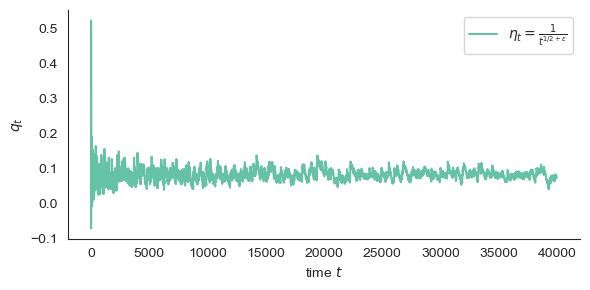

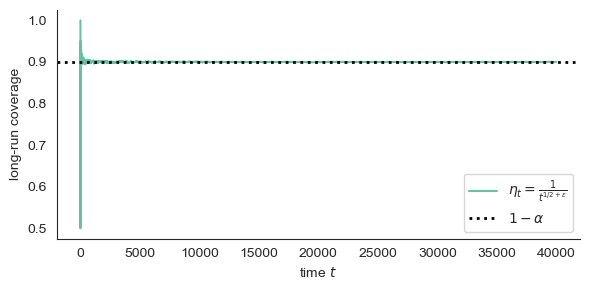

0.08319245519369417


In [89]:
# Get predictions
yhat_sa_jd = causal_ma(y_observed.to_numpy(), w=15)

yhat_sa_jd = np.asarray(yhat_sa_jd, dtype=float)

valid = ~np.isnan(yhat_sa_jd)
y_true_jd = y_true[valid]
yhat_sa_jd = yhat_sa_jd[valid]
# Compute coverage
results_jd_sa = compute_coverage_metrics(
    y_true_jd,
    yhat_sa_jd,
    alpha=0.1, epsilon=0.1, W=1000, C=1
)

plot_coverage_results(results_jd_sa, alpha=0.1, W=1000)
print(np.mean(results_jd_sa['q_decaying']))
CI_ma_decaying = results_jd_sa['q_decaying'] * 2

### Naive Forecast 

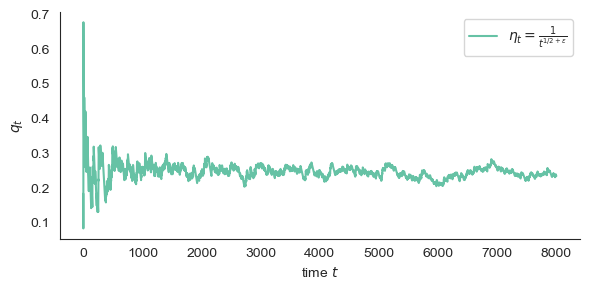

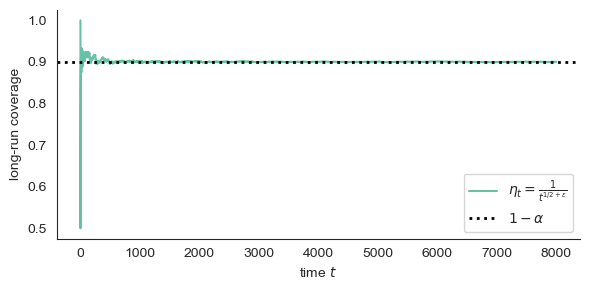

0.24682650776022577


In [ ]:
def rw_drift_forecast(data, train_size):
    """
    Random Walk with Drift forecasting:
    next value = previous value + drift,
    where drift is the average change in the training set.

    Parameters:
        data (pd.Series or np.array): Time series data.
        train_size (int): Number of points in the training set.

    Returns:
        np.array: RW with drift predictions for the test set.
    """
    data = np.asarray(data, dtype=float)
    train_data = data[:train_size]
    test_data = data[train_size:]

    # compute average drift from training set
    drift = np.mean(np.diff(train_data))

    predictions = []
    last_value = train_data[-1]
    for _ in test_data:
        next_value = last_value + drift
        predictions.append(next_value)
        # update last_value with "actual observed" to keep walk-forward style
        last_value = _  

    return np.array(predictions)



y_rw_pred = rw_drift_forecast(y_observed.to_numpy(), train_size3)
y_rw_pred = np.asarray(y_rw_pred, dtype=float)
y_rw_pred = y_rw_pred[~np.isnan(y_rw_pred)]

# coverage
results_jd_rw = compute_coverage_metrics(
    y_true_test,
    y_rw_pred,
    alpha=0.1, epsilon=0.1, W=1000, C=1
)
plot_coverage_results(results_jd_rw, alpha=0.1, W=1000)
print(np.mean(results_jd_rw['q_decaying']))
CI_rw_decaying = results_jd_rw['q_decaying'] * 2

In [135]:
print(f'mean coverage for random walk is:', np.mean(results_jd_rw['observed_coverages_decaying']))

mean coverage for random walk is: 0.9005


## SARIMAX

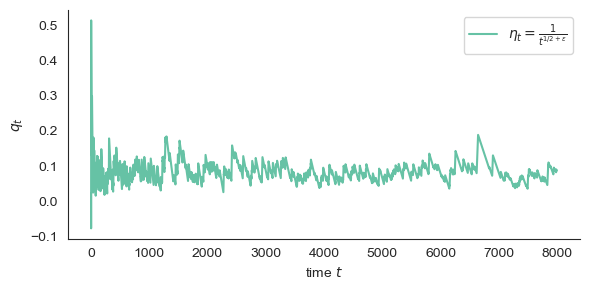

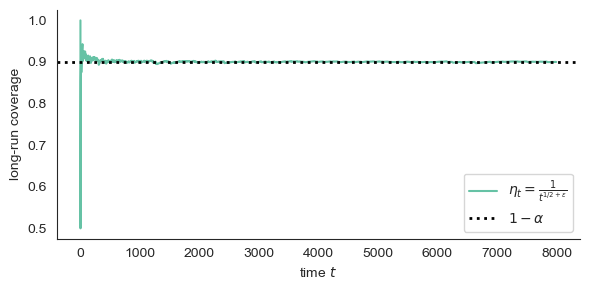

0.0847756241689397


In [56]:
results_jd_srm_model1 = compute_coverage_metrics(Y_jd_srm_model1[4:], Yhat_jd_srm_model1, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_jd_srm_model1, alpha=0.1, W=1000)
print(np.mean(results_jd_srm_model1['q_decaying']))
CI_sarimax_decaying_model1 = results_jd_srm_model1['q_decaying'] * 2 

# LSTM Grid Search 

In [50]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from sklearn.model_selection import train_test_split

seq_length = 15
X_train, X_test, y_train, y_test = create_sequences(y_observed, seq_length, train_ratio=0.8)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, shuffle=False
)

# --- Define Tunable Model ---
def build_model(hp):
    model = Sequential()
    
    # Narrower but meaningful search space
    units_1 = hp.Choice('units_1', values=[128, 256])
    units_2 = hp.Choice('units_2', values=[64, 96])
    dropout = hp.Choice('dropout', values=[0.1, 0.2])
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4])
    huber_delta = hp.Choice('huber_delta', values=[1.0, 2.0])  # tune robustness
    
    model.add(LSTM(units_1, activation='tanh', return_sequences=True, 
                   recurrent_dropout=0.1, input_shape=(seq_length, 1)))
    model.add(Dropout(dropout))
    model.add(LSTM(units_2, activation='tanh', recurrent_dropout=0.1))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.Huber(delta=huber_delta)
    )
    return model

# --- GridSearch Setup ---
tuner = kt.GridSearch(
    build_model,
    objective='val_loss',
    directory='lstm_grid_heavy_tailed_jumps',
    project_name='stock_prediction_grid',
    overwrite=True
)

# --- Perform Search ---
print("Starting grid search...")
tuner.search(
    X_train, y_train,
    epochs=20,   # shorter training, early stopping will cut earlier
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)

# --- Get Best Hyperparameters ---
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
best_epoch = best_trial.best_step
print("Best epoch found:", best_epoch)

print("\n--- Grid Search Complete ---")
print(f"Optimal units L1: {best_hps.get('units_1')}")
print(f"Optimal units L2: {best_hps.get('units_2')}")
print(f"Optimal dropout: {best_hps.get('dropout')}")
print(f"Optimal learning rate: {best_hps.get('learning_rate')}")
print(f"Optimal Huber delta: {best_hps.get('huber_delta')}")

Trial 32 Complete [00h 06m 33s]
val_loss: 0.012331177480518818

Best val_loss So Far: 0.01233088131994009
Total elapsed time: 01h 22m 25s
Best epoch found: 6

--- Grid Search Complete ---
Optimal units L1: 256
Optimal units L2: 64
Optimal dropout: 0.1
Optimal learning rate: 0.0005
Optimal Huber delta: 1.0


Epoch 1/6


/Users/victoria/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 0.0184
Epoch 2/6
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 0.0138
Epoch 3/6
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 0.0138
Epoch 4/6
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 0.0137
Epoch 5/6
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 0.0135
Epoch 6/6
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0134
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


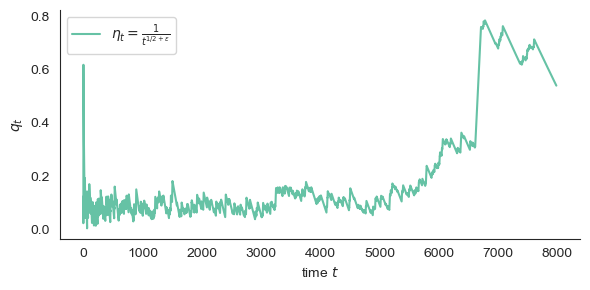

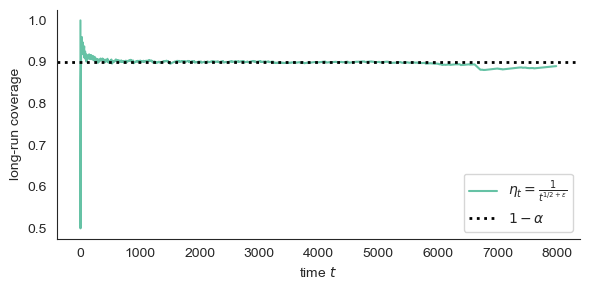

0.21924097779924293


In [51]:
from tensorflow.keras.layers import Dropout


seq_length = 15

X_train, X_test, y_train, y_test = create_sequences(y_observed, seq_length, train_ratio = 0.8)

model = Sequential([
    LSTM(256, activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.1),
    LSTM(64, activation='tanh'),
    Dropout(0.1),
    Dense(1)
])

model.compile(tf.keras.optimizers.Adam(learning_rate=0.0005), loss=tf.keras.losses.Huber(delta=1.0))
history = model.fit(X_train, y_train, epochs=6, batch_size= 16)
y_pred_lstm_sim3_model1 = model.predict(X_test).flatten()


results_jd_lstm3_model1 = compute_coverage_metrics(y_true_test[seq_length:], y_pred_lstm_sim3_model1, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_jd_lstm3_model1, alpha=0.1, W=1000)
print(np.mean(results_jd_lstm3_model1['q_decaying']))
CI_lstm_decaying_model1 = results_jd_lstm3_model1['q_decaying'] * 2


In [136]:
print(f'mean coverage for lstm is:', np.mean(results_jd_lstm3_model1['observed_coverages_decaying']))

mean coverage for lstm is: 0.8900438321853475


# Super Learner 

In [120]:
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from scipy.optimize import minimize
import numpy as np
import pandas as pd

# --- Parameters ---
seq_length = 15
n_splits = 5
lstm_configs = [ {"units1": 256, "units2": 64, "dropout": 0.1}]

data_scaled = y_observed.values.astype(float)
n_total = len(data_scaled)
train_size = int(0.8 * n_total)

# Number of base learners
n_learners = 3

meta_features = np.full((train_size - seq_length, n_learners), np.nan)
meta_targets  = y_true[seq_length:train_size]
train_data_scaled = data_scaled[:train_size]

tscv = TimeSeriesSplit(n_splits=n_splits)

X_all, _, y_all, _ = create_sequences(data_scaled, seq_length, train_ratio=0.8)
for fold, (train_idx, val_idx) in enumerate(tscv.split(train_data_scaled)):
    col = 0

    # ensure val_idx has only usable points
    mask = val_idx >= seq_length
    if not np.any(mask):
        continue
    val_idx_eff = val_idx[mask]
    rows = val_idx_eff - seq_length

    # Naive
    naive_preds_all = rw_drift_forecast(train_data_scaled[:val_idx[-1]+1], len(train_idx))
    meta_features[rows, col] = naive_preds_all[-len(val_idx_eff):]
    col += 1

    # GARCH
    garch_preds = garch_forecast(train_data_scaled[:val_idx[-1]+1],
                                len(train_idx),
                                mean='AR', lags=1, p=1, q=1, dist='t',
                                refit_every=20)   # faster
    meta_features[rows, col] = garch_preds[-len(val_idx_eff):]
    col += 1

    # LSTM
    tr_rows = train_idx[train_idx >= seq_length] - seq_length
    va_rows = val_idx_eff - seq_length

    X_tr, y_tr = X_all[tr_rows], y_all[tr_rows]
    X_va, y_va = X_all[va_rows], y_all[va_rows]

    for config in lstm_configs:
        lstm_model = Sequential([
            LSTM(config["units1"], activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
            Dropout(config["dropout"]),
            LSTM(config["units2"], activation='tanh'),
            Dropout(config["dropout"]),
            Dense(1)
        ])
        lstm_model.compile(tf.keras.optimizers.Adam(learning_rate=0.0005), loss=tf.keras.losses.Huber(delta=1.0))
        lstm_model.fit(X_tr, y_tr, epochs=6, batch_size=16, verbose=0)
        lstm_preds = lstm_model.predict(X_va).flatten()
        meta_features[rows, col] = lstm_preds
        col += 1

# drop any rows that remain NaN (early folds may be partially masked)
valid_rows = ~np.isnan(meta_features).any(axis=1)
X_meta = meta_features[valid_rows]
y_meta = meta_targets[valid_rows]

def optimize_weights(X, y, alpha1=0.0, alpha2=0.0):
    """
    Optimize convex weights with MSE loss.
    Optionally add L1 (alpha1) and L2 (alpha2) regularization.
    """
    init_phi = np.ones(X.shape[1]) / X.shape[1]

    def mse_loss(phi):
        y_pred = X @ phi
        mse = np.mean((y - y_pred) ** 2)
        l1 = alpha1 * np.sum(np.abs(phi))
        l2 = alpha2 * np.sum(phi**2)
        return mse + l1 + l2

    constraints = [{'type': 'eq', 'fun': lambda phi: np.sum(phi) - 1}]
    bounds = [(0, 1)] * X.shape[1]

    result = minimize(mse_loss, init_phi, bounds=bounds, constraints=constraints)
    return result.x

meta_weights = optimize_weights(X_meta, y_meta, alpha1=0, alpha2=0)
print("Meta-learner weights:", meta_weights)

# --- Final training on full data for test-time preds ---
# Build test stacks aligned to y_test_full (sequence-based)
X_train_full, X_test_full, y_train_full, y_test_full = create_sequences(data_scaled, seq_length, train_ratio = 0.8)
n_test = len(y_test_full)

# Naive full-series predictions
naive_full_preds = rw_drift_forecast(data_scaled, train_size)
naive_full_preds = naive_full_preds[-n_test:]

# GARCH 
garch_full_preds = []
garch_preds_all = garch_forecast(data_scaled,
                                 train_size,
                                 mean='AR', lags=1,
                                 p=1, q=1, dist='t',
                                 refit_every=20)
garch_full_preds.append(garch_preds_all[-n_test:])

# LSTM 
lstm_full_preds = []
for config in lstm_configs:
    lstm_model_full = Sequential([
        LSTM(config["units1"], activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
        Dropout(config["dropout"]),
        LSTM(config["units2"], activation='tanh'),
        Dropout(config["dropout"]),
        Dense(1)
    ])
    lstm_model_full.compile(tf.keras.optimizers.Adam(learning_rate=0.0005), loss=tf.keras.losses.Huber(delta=1.0))
    lstm_model_full.fit(X_train_full, y_train_full, epochs=6, batch_size=16, verbose=0)
    preds = lstm_model_full.predict(X_test_full).flatten()
    lstm_full_preds.append(preds)

X_test_meta = np.column_stack(
    [naive_full_preds] + 
    garch_full_preds +
    lstm_full_preds
)
super_preds_scaled = X_test_meta @ meta_weights

  0%|          | 0/5333 [00:00<?, ?it/s]/Users/victoria/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.04393. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
  0%|          | 1/5333 [00:00<19:47,  4.49it/s]/Users/victoria/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.04391. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting res

167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


  0%|          | 0/5333 [00:00<?, ?it/s]/Users/victoria/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.04348. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/victoria/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.04345. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
  0%|          | 2

167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


  0%|          | 0/5333 [00:00<?, ?it/s]/Users/victoria/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.04366. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
  0%|          | 1/5333 [00:00<14:15,  6.23it/s]/Users/victoria/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.04367. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting res

...

167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


  0%|          | 0/5333 [00:00<?, ?it/s]/Users/victoria/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0436. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
  0%|          | 1/5333 [00:00<13:08,  6.76it/s]/Users/victoria/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.04358. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting resc

167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Meta-learner weights: [0.12629098 0.07494826 0.79876076]


  0%|          | 0/8000 [00:00<?, ?it/s]/Users/victoria/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0434. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
  0%|          | 1/8000 [00:00<26:14,  5.08it/s]/Users/victoria/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.04341. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting resc

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [122]:
print("\nTest RMSEs:")
print("Naive:", np.sqrt(mean_squared_error(y_true_test, y_rw_pred)))
print("GARCH:", np.sqrt(mean_squared_error(y_true_test, y_garch_pred)))
print("LSTM:", np.sqrt(mean_squared_error(y_true_test[seq_length:], y_pred_lstm_sim3_model1)))
print("Super Learner:", np.sqrt(mean_squared_error(y_true_test[seq_length:], super_preds_scaled)))
print("R² Score:", r2_score(y_true_test[seq_length:], super_preds_scaled))
print("Meta-Learner Weights:", meta_weights)


Test RMSEs:
Naive: 0.15022612740534397
GARCH: 0.16507035680894547
LSTM: 0.2789851004853252
Super Learner: 0.22380360455858928
R² Score: 0.9448529359480251
Meta-Learner Weights: [0.12629098 0.07494826 0.79876076]


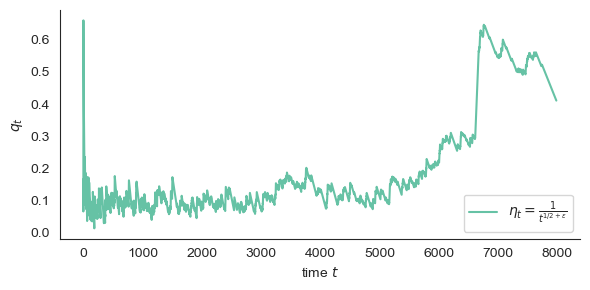

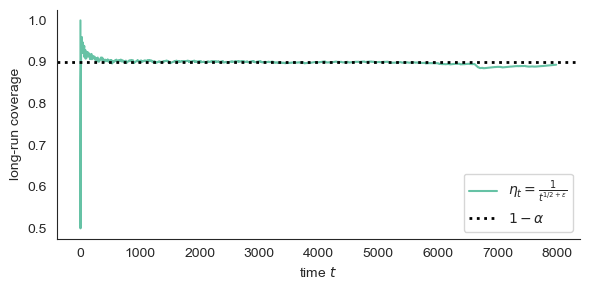

0.20204773250112973


In [123]:
results_data_sp = compute_coverage_metrics(y_true_test[seq_length:], super_preds_scaled, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_data_sp, alpha=0.1, W=1000)
CI_sp_decaying = results_data_sp['q_decaying'] * 2 
print(np.mean(results_data_sp['q_decaying']))

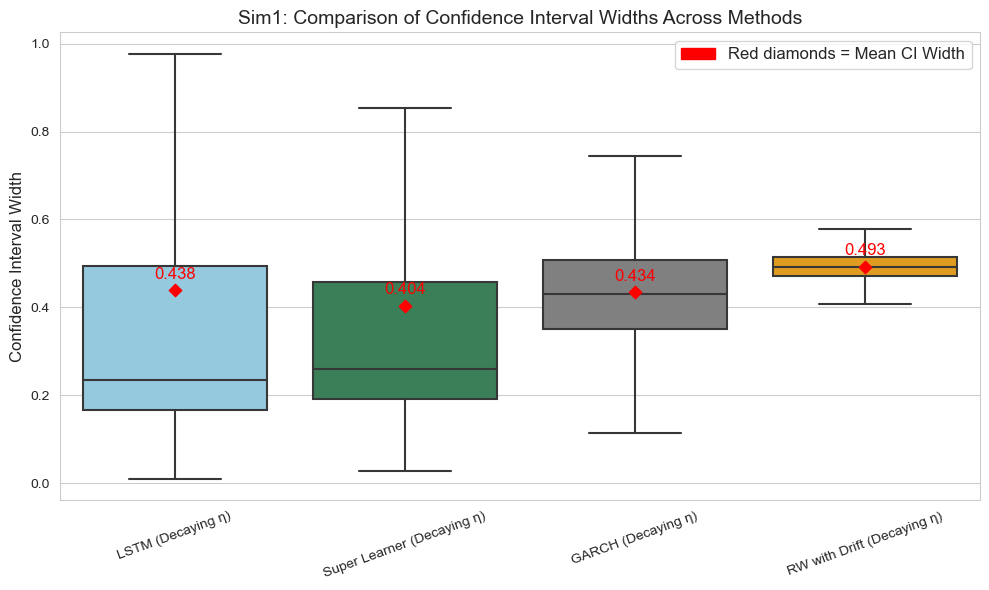

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
n = len(CI_lstm_decaying_model1)
# Step 1: Collect all CI width arrays into a dictionary
data_dict = {
    "GARCH (Decaying η)": CI_garch_decaying[-n:],
    "RW with Drift (Decaying η)": CI_rw_decaying[-n:],
    "LSTM (Decaying η)": CI_lstm_decaying_model1,
    "Super Learner (Decaying η)": CI_sp_decaying[-n:]
}

# Step 2: Convert to long-format DataFrame
df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")

# Step 3: Define custom order by median CI width
order = df_long.groupby("Method")["CI Width"].median().sort_values().index

# Step 4: Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
palette = {
    "GARCH (Decaying η)": "gray",
    "RW with Drift (Decaying η)": "orange",
    "LSTM (Decaying η)": "skyblue",
    "Super Learner (Decaying η)": "seagreen"
}

ax = sns.boxplot(x="Method", y="CI Width", data=df_long, order=order,
                 palette=palette, showfliers=False)

# Add mean points
means = df_long.groupby("Method")["CI Width"].mean()
for i, method in enumerate(order):
    ax.scatter(i, means[method], color="red", marker="D", s=40, zorder=3)
    ax.text(i, means[method]+0.02, f"{means[method]:.3f}",
            ha='center', va='bottom', fontsize=12, color="red")

# Step 5: Add custom legend entry for red mean points
mean_patch = mpatches.Patch(color='red', label='Red diamonds = Mean CI Width')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [mean_patch], labels + ['Red diamonds = Mean CI Width'],
          loc='upper right', fontsize=12, frameon=True)

# Step 6: Enhance readability
plt.title("Sim1: Comparison of Confidence Interval Widths Across Methods", fontsize=14)
plt.xlabel("")
plt.ylabel("Confidence Interval Width", fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [137]:
print(f'mean coverage for super learner is:', np.mean(results_data_sp['observed_coverages_decaying']))

mean coverage for super learner is: 0.893425172197871


# COMA

Mean deterministic coverage: 0.8892924232936756
Mean randomized coverage: 0.8892924232936756
Mean CI width — COMA (det): 0.4340867218287179
Mean CI width — COMA (rand): 0.43365215889392805
Mean CI width — Super Learner: 0.40409546500225946


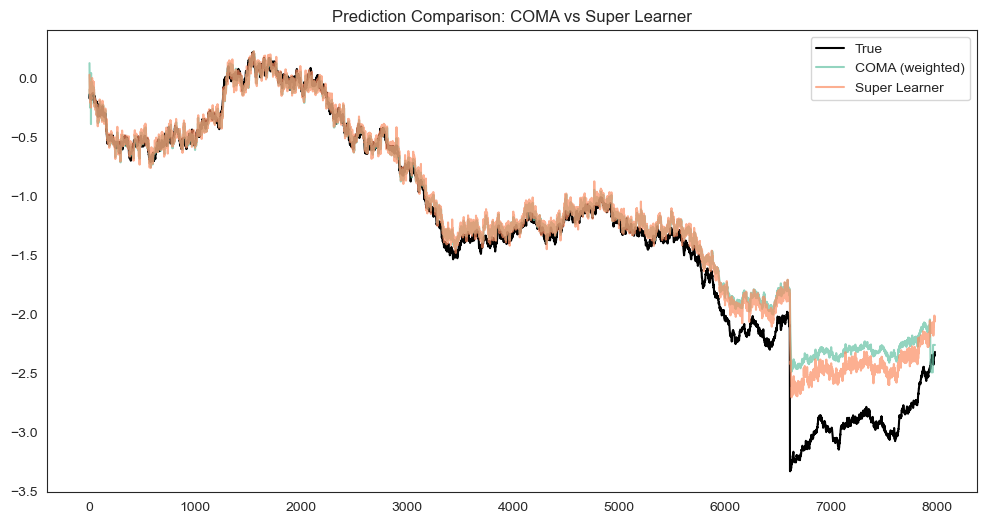

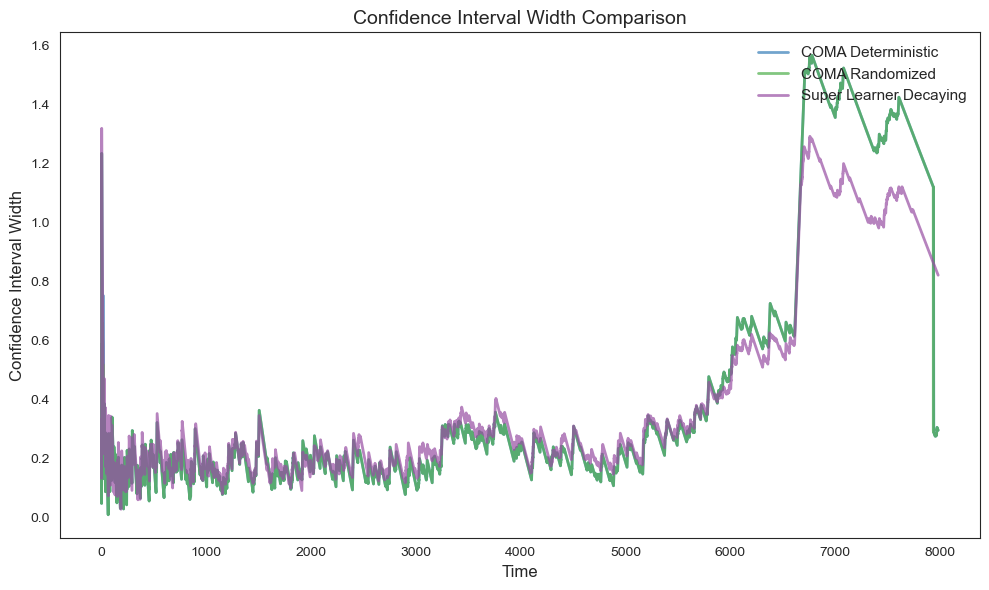

In [139]:
colors = sns.color_palette("Set1", 4)
# --- Step 1: Minimum aligned length ---
min_len = min(
    len(results_garch['q_decaying']),
    len(results_jd_rw['q_decaying']),
    #len(results_jd_srm_model2['q_decaying']),
    len(results_jd_lstm3_model1['q_decaying']),
    #len(results_jd_lstm3_model2['q_decaying']),
    len(CI_sp_decaying),
    len(y_true_test)
)

# --- Step 2: CI half-widths (2 * q_decaying) ---
ci_matrix = np.column_stack([
    CI_garch_decaying[-min_len:],
    CI_rw_decaying[-min_len:],
    #2 * results_jd_srm_model2['q_decaying'][-min_len:],
    CI_lstm_decaying_model1[-min_len:],
    #2 * results_jd_lstm3_model2['q_decaying'][:min_len]

])
adahedAlg = adahedge(loss_matrix=ci_matrix)

intervals_garch = np.column_stack([
    y_garch_pred[-min_len:] 
    - results_garch['q_decaying'][-min_len:],
    y_garch_pred[-min_len:] 
    + results_garch['q_decaying'][-min_len:]
])

intervals_naive = np.column_stack([
    y_rw_pred[-min_len:] - results_jd_rw['q_decaying'][-min_len:],
    y_rw_pred[-min_len:] + results_jd_rw['q_decaying'][-min_len:]
])

intervals_lstm1 = np.column_stack([
    y_pred_lstm_sim3_model1[-min_len:] - results_jd_lstm3_model1['q_decaying'][-min_len:],
    y_pred_lstm_sim3_model1[-min_len:] + results_jd_lstm3_model1['q_decaying'][-min_len:]
])


intervals_list_plain = [intervals_garch, intervals_naive, intervals_lstm1]
weights_plain = adahedAlg["weights"]

# --- Step 5: Align test labels ---
y_test_aligned = y_true_test[-min_len:]

# --- Step 6: Run COMA ---
result_plain = coma_loop(intervals_list_plain, weights_plain, y_test_aligned)

print("Mean deterministic coverage:", result_plain["mean_m_cov"])
print("Mean randomized coverage:", result_plain["mean_wm_cov"])

# --- Step 7: Compute widths ---
pi_m   = result_plain["pi_m"]
pi_wm  = result_plain["pi_wm"]

coma_width_det  = np.array([loss_fun(ci) for ci in pi_m])
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm])

CI_super_decaying = CI_sp_decaying[-min_len:]

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — Super Learner:", np.mean(CI_super_decaying))

base_preds_matrix = np.column_stack([
    y_garch_pred[-min_len:],
    y_rw_pred[-min_len:],
    y_pred_lstm_sim3_model1[-min_len:]
])
# Case 1: weights_plain is shape (n, k)
coma_preds_weighted = np.sum(base_preds_matrix * weights_plain, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(y_test_aligned, label="True", color="black")
plt.plot(coma_preds_weighted, label="COMA (weighted)", alpha=0.7)
plt.plot(super_preds_scaled[-min_len:], label="Super Learner", alpha=0.7)
plt.legend()
plt.title("Prediction Comparison: COMA vs Super Learner")
plt.show()

# --- Step 8: Plot ---
plt.figure(figsize=(10, 6))

plt.plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha = 0.7, color=colors[1])
plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha = 0.7, color=colors[2])
plt.plot(CI_super_decaying, label='Super Learner Decaying', linewidth=2, alpha = 0.7, color=colors[3])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
plt.title('Confidence Interval Width Comparison', fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

Mean deterministic coverage: 0.8895428929242329
Mean randomized coverage: 0.8892924232936756
Mean CI width — COMA (det): 0.4340867218287179
Mean CI width — COMA (rand): 0.4335204725395203
Mean CI width — COMA (det) + SL: 0.4041902866380989
Mean CI width — COMA (rand) + SL: 0.40387676497000846


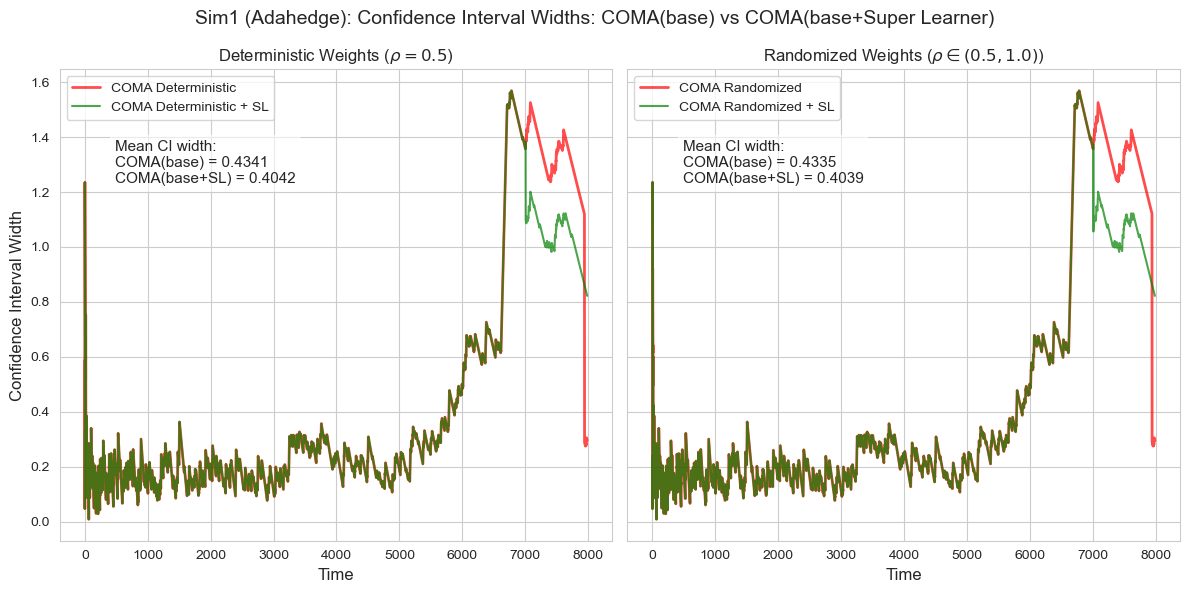

In [152]:

min_len = min(
    len(results_garch['q_decaying']),
    len(results_jd_rw['q_decaying']),
    len(results_jd_lstm3_model1['q_decaying']),
    #len(results_jd_lstm3_model2['q_decaying']),
    len(results_data_sp['q_decaying']),
    len(y_true_test)
)

ci_matrix_sl = np.column_stack([
    CI_garch_decaying[-min_len:],
    CI_rw_decaying[-min_len:],
    #2 * results_jd_srm_model2['q_decaying'][-min_len:],
    CI_lstm_decaying_model1[-min_len:],
    CI_sp_decaying[-min_len:]
])
adahedAlg_sl = adahedge(loss_matrix=ci_matrix_sl)

intervals_garch = np.column_stack([
    y_garch_pred[-min_len:] 
    - results_garch['q_decaying'][-min_len:],
    y_garch_pred[-min_len:] 
    + results_garch['q_decaying'][-min_len:]
])

intervals_rw = np.column_stack([
    y_rw_pred[-min_len:] - results_jd_rw['q_decaying'][-min_len:],
    y_rw_pred[-min_len:] + results_jd_rw['q_decaying'][-min_len:]
])


intervals_lstm1 = np.column_stack([
    y_pred_lstm_sim3_model1[-min_len:] - results_jd_lstm3_model1['q_decaying'][-min_len:],
    y_pred_lstm_sim3_model1[-min_len:] + results_jd_lstm3_model1['q_decaying'][-min_len:]
])



intervals_sp = np.column_stack([
    super_preds_scaled[-min_len:] - results_data_sp['q_decaying'][-min_len:],
    super_preds_scaled[-min_len:] + results_data_sp['q_decaying'][-min_len:]
])

# --- Step 4: Pack intervals + weights ---
intervals_list_sl = [intervals_garch, intervals_rw, intervals_lstm1, intervals_sp]
weights_sl = adahedAlg_sl["weights"]

# --- Step 5: Align test labels ---
y_test_aligned = y_true_test[-min_len:]

# --- Step 6: Run COMA ---
result_sl = coma_loop(intervals_list_sl, weights_sl, y_test_aligned)

print("Mean deterministic coverage:", result_sl["mean_m_cov"])
print("Mean randomized coverage:", result_sl["mean_wm_cov"])


intervals_list_plain = [intervals_garch, intervals_rw, intervals_lstm1]
weights_plain = adahedAlg["weights"]

# --- Step 5: Align test labels ---
y_test_aligned = y_true_test[-min_len:]

# --- Step 6: Run COMA ---
result_plain = coma_loop(intervals_list_plain, weights_plain, y_test_aligned)
# --- Step 7: Compute widths ---
pi_m_plain   = result_plain["pi_m"]
pi_wm_plain  = result_plain["pi_wm"]
coma_width_det  = np.array([loss_fun(ci) for ci in pi_m_plain])
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm_plain])
# --- Step 7: Compute widths ---
pi_m_sl   = result_sl["pi_m"]
pi_wm_sl  = result_sl["pi_wm"]

coma_width_det_sl  = np.array([loss_fun(ci) for ci in pi_m_sl])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA (det) + SL:", np.nanmean(coma_width_det_sl))
print("Mean CI width — COMA (rand) + SL:", np.nanmean(coma_width_rand_sl))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot ---
axes[0].plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color='red')
axes[0].plot(coma_width_det_sl, label='COMA Deterministic + SL', linewidth=1.5, alpha=0.7, color='green')
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Add mean values annotation
mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.1, 0.85,
             f"Mean CI width:\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# --- Randomized subplot ---
axes[1].plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color='red')
axes[1].plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color='green')
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time", fontsize=12)
axes[1].legend()

# Add mean values annotation
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.1, 0.85,
             f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Sim1 (Adahedge): Confidence Interval Widths: COMA(base) vs COMA(base+Super Learner)", fontsize=14)
plt.tight_layout()
plt.show()

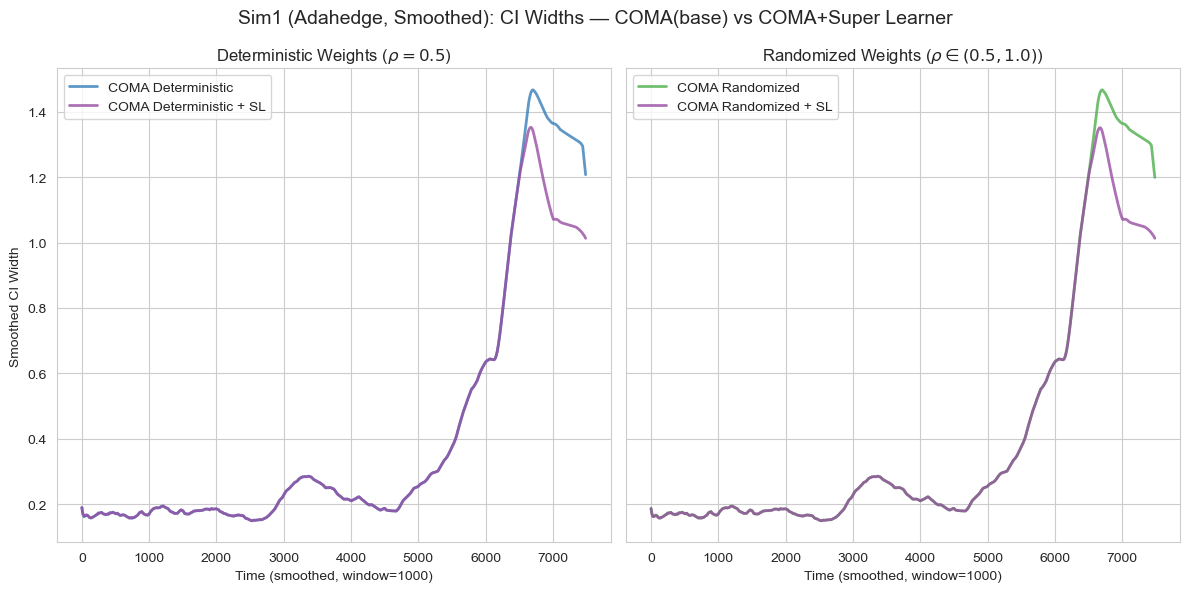

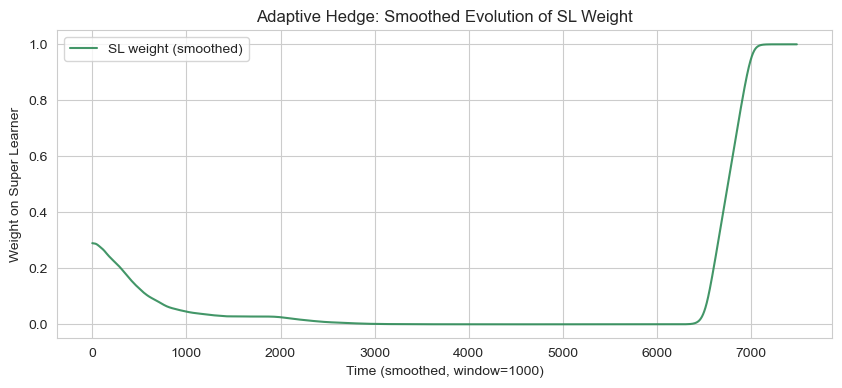

In [151]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Helper function for smoothing ---
def smooth_series(series, window=500):
    return np.convolve(series, np.ones(window)/window, mode='valid')

window = 500  # smoothing window size

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot (smoothed) ---
axes[0].plot(smooth_series(coma_width_det, window), label='COMA Deterministic', linewidth=2, alpha=0.8, color=colors[1])
axes[0].plot(smooth_series(coma_width_det_sl, window), label='COMA Deterministic + SL', linewidth=2, alpha=0.8, color=colors[3])
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time (smoothed, window=1000)")
axes[0].set_ylabel("Smoothed CI Width")
axes[0].legend()

# --- Randomized subplot (smoothed) ---
axes[1].plot(smooth_series(coma_width_rand, window), label='COMA Randomized', linewidth=2, alpha=0.8, color=colors[2])
axes[1].plot(smooth_series(coma_width_rand_sl, window), label='COMA Randomized + SL', linewidth=2, alpha=0.8, color=colors[3])
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time (smoothed, window=1000)")
axes[1].legend()

plt.suptitle("Sim1 (Adahedge, Smoothed): CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

# --- Smooth SL weight plot ---
plt.figure(figsize=(10,4))
plt.plot(smooth_series(weights_sl[:, -1], window), label="SL weight (smoothed)", alpha=0.9, color="seagreen")
plt.xlabel("Time (smoothed, window=1000)")
plt.ylabel("Weight on Super Learner")
plt.title("Adaptive Hedge: Smoothed Evolution of SL Weight")
plt.legend()
plt.show()

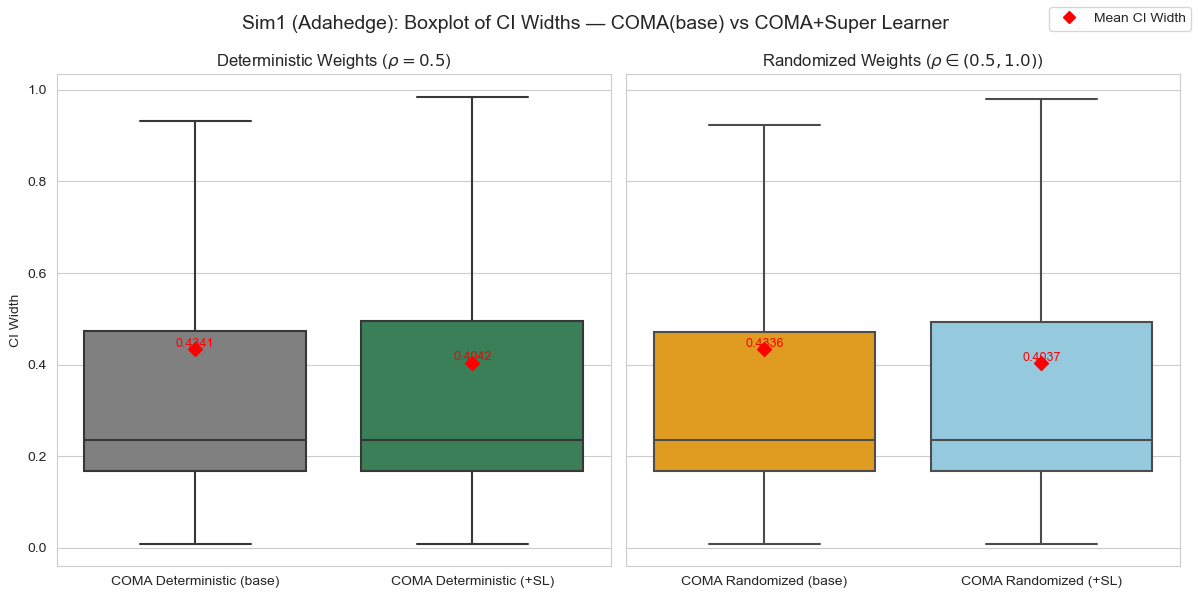

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Collect into dictionary
data_dict = {
    "COMA Deterministic (base)": coma_width_det,
    "COMA Deterministic (+SL)": coma_width_det_sl,
    "COMA Randomized (base)": coma_width_rand,
    "COMA Randomized (+SL)": coma_width_rand_sl
}

# Convert to DataFrame
df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")

# Split deterministic vs randomized
det_methods = ["COMA Deterministic (base)", "COMA Deterministic (+SL)"]
rand_methods = ["COMA Randomized (base)", "COMA Randomized (+SL)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

palette = {"COMA Deterministic (base)": "gray",
           "COMA Deterministic (+SL)": "seagreen",
           "COMA Randomized (base)": "orange",
           "COMA Randomized (+SL)": "skyblue"}

# --- Deterministic subplot ---
sns.boxplot(x="Method", y="CI Width", data=df_long[df_long["Method"].isin(det_methods)],
            order=det_methods, palette=palette, showfliers=False, ax=axes[0])

means_det = [np.nanmean(data_dict[m]) for m in det_methods]
for i, m in enumerate(det_methods):
    axes[0].scatter(i, means_det[i], color="red", marker="D", s=50, zorder=3)
    axes[0].text(i, means_det[i]+0.005, f"{means_det[i]:.4f}", ha='center', fontsize=9, color="red")

axes[0].set_title("Deterministic Weights ($\\rho=0.5$)")
axes[0].set_xlabel("")
axes[0].set_ylabel("CI Width")

# --- Randomized subplot ---
sns.boxplot(x="Method", y="CI Width", data=df_long[df_long["Method"].isin(rand_methods)],
            order=rand_methods, palette=palette, showfliers=False, ax=axes[1])

means_rand = [np.nanmean(data_dict[m]) for m in rand_methods]
for i, m in enumerate(rand_methods):
    axes[1].scatter(i, means_rand[i], color="red", marker="D", s=50, zorder=3)
    axes[1].text(i, means_rand[i]+0.005, f"{means_rand[i]:.4f}", ha='center', fontsize=9, color="red")

axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

# Legend for red diamond
fig.legend(handles=[plt.Line2D([0],[0], color='red', marker='D', linestyle='', label='Mean CI Width')],
           loc='upper right')

plt.suptitle("Sim1 (Adahedge): Boxplot of CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

### Hedge

Mean deterministic coverage (COMA base): 0.8895428929242329
Mean randomized coverage (COMA base): 0.8879148403256105
Mean deterministic coverage (COMA+SL): 0.8897933625547902
Mean randomized coverage (COMA+SL): 0.8855353788353162
Mean CI width — COMA(base, det): 0.43446749424606806
Mean CI width — COMA(base, rand): 0.431463684950547
Mean CI width — COMA(base+SL, det): 0.4045376833417101
Mean CI width — COMA(base+SL, rand): 0.40087029879889935


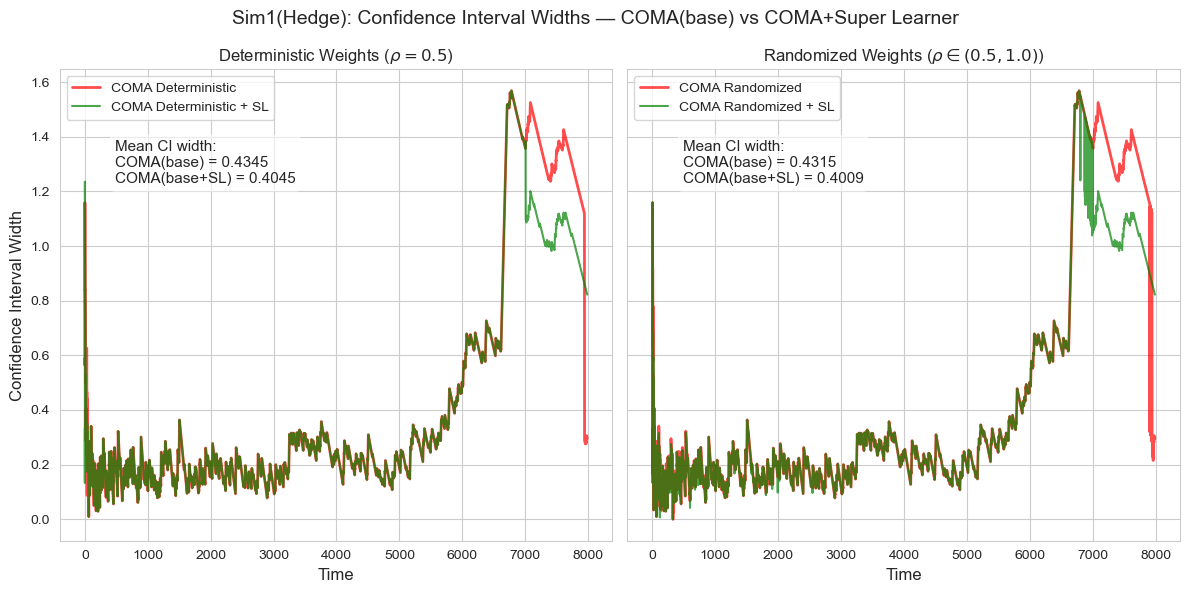

In [159]:
# --- Step 1: Run Hedge separately for base (3 experts) and base+SL (4 experts) ---
hedAlg_base = hedge(ci_matrix, eta=0.1)        # shape (N,3)
hedAlg_sl   = hedge(ci_matrix_sl, eta=0.1)     # shape (N,4)

weights_base = hedAlg_base["weights"]
weights_sl   = hedAlg_sl["weights"]

N_base, K_base = weights_base.shape
N_sl, K_sl     = weights_sl.shape

# Ensure alignment
min_len = min(len(y_true_test), N_base, N_sl)
y_test_aligned = y_true_test[-min_len:]

# --- Step 2: Preallocate ---
pi_m_base, pi_wm_base = [], []
pi_m_sl, pi_wm_sl     = [], []

m_cov_base = np.full(min_len, np.nan)
wm_cov_base = np.full(min_len, np.nan)
m_cov_sl   = np.full(min_len, np.nan)
wm_cov_sl  = np.full(min_len, np.nan)

# --- Step 3: Loop over time ---
for i in range(min_len):
    # --- Sample ONE rho per step and reuse for both base and base+SL ---
    rho_rand = np.random.uniform(0.5,1.0)

    # --- Base (3 experts) ---
    conf_base = np.vstack([intervals_list_plain[j][i] for j in range(3)])
    maj_int_base = majority_vote(conf_base, w=weights_base[i], rho=0.5)
    wmaj_int_base = majority_vote(conf_base, w=weights_base[i], rho=rho_rand)

    pi_m_base.append(maj_int_base)
    pi_wm_base.append(wmaj_int_base)
    m_cov_base[i]  = covr_fun(maj_int_base, y_test_aligned[i])
    wm_cov_base[i] = covr_fun(wmaj_int_base, y_test_aligned[i])

    # --- Base+SL (4 experts) ---
    conf_sl = np.vstack([intervals_list_sl[j][i] for j in range(4)])
    maj_int_sl = majority_vote(conf_sl, w=weights_sl[i], rho=0.5)
    wmaj_int_sl = majority_vote(conf_sl, w=weights_sl[i], rho=rho_rand)  # same rho_rand

    pi_m_sl.append(maj_int_sl)
    pi_wm_sl.append(wmaj_int_sl)
    m_cov_sl[i]  = covr_fun(maj_int_sl, y_test_aligned[i])
    wm_cov_sl[i] = covr_fun(wmaj_int_sl, y_test_aligned[i])

# --- Step 4: Compute widths ---
coma_width_det     = np.array([loss_fun(ci) for ci in pi_m_base])
coma_width_rand    = np.array([loss_fun(ci) for ci in pi_wm_base])
coma_width_det_sl  = np.array([loss_fun(ci) for ci in pi_m_sl])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

# --- Step 5: Summaries ---
print("Mean deterministic coverage (COMA base):", np.nanmean(m_cov_base))
print("Mean randomized coverage (COMA base):", np.nanmean(wm_cov_base))
print("Mean deterministic coverage (COMA+SL):", np.nanmean(m_cov_sl))
print("Mean randomized coverage (COMA+SL):", np.nanmean(wm_cov_sl))

print("Mean CI width — COMA(base, det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA(base+SL, det):", np.nanmean(coma_width_det_sl))
print("Mean CI width — COMA(base+SL, rand):", np.nanmean(coma_width_rand_sl))

# --- Step 7: Subplot comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot ---
axes[0].plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color='red')
axes[0].plot(coma_width_det_sl, label='COMA Deterministic + SL', linewidth=1.5, alpha=0.7, color='green')
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Annotate means
mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.1, 0.85,
             f"Mean CI width:\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# --- Randomized subplot ---
axes[1].plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color='red')
axes[1].plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color='green')
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time", fontsize=12)
axes[1].legend()

# Annotate means
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.1, 0.85,
             f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Sim1(Hedge): Confidence Interval Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

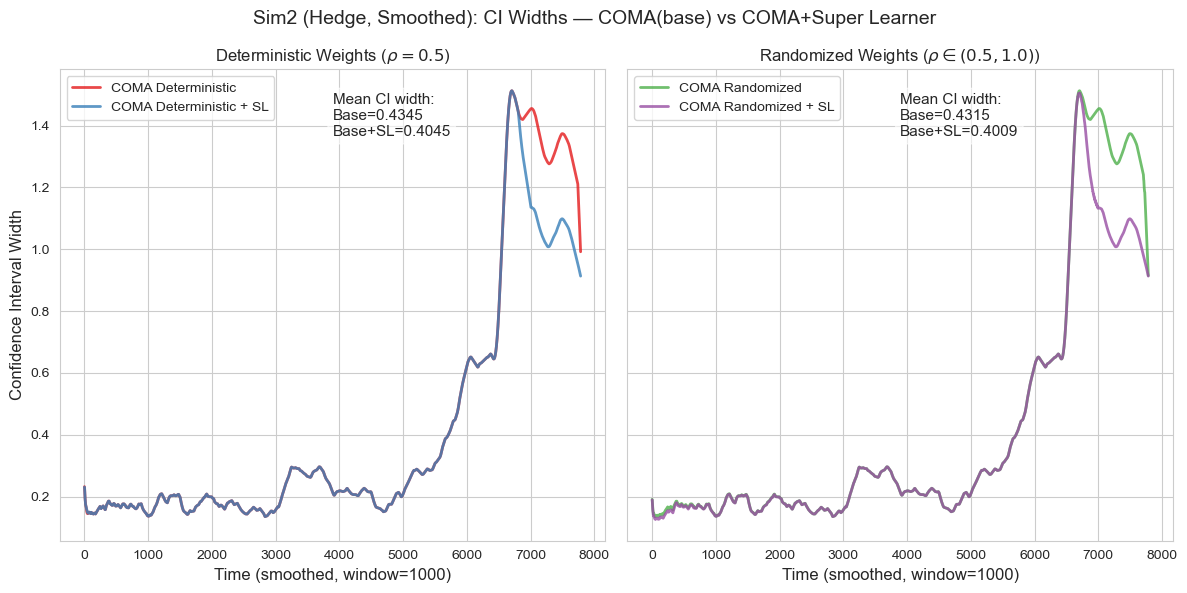

In [161]:
import numpy as np
import matplotlib.pyplot as plt

# --- Helper function for smoothing ---
def smooth_series(series, window=500):
    """Apply rolling mean smoothing with specified window size."""
    return np.convolve(series, np.ones(window)/window, mode='valid')

# --- Step 7: Subplot comparison (smoothed) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

window = 200  # <-- adjust this for stronger/weaker smoothing

# --- Deterministic subplot ---
axes[0].plot(smooth_series(coma_width_det, window), 
             label='COMA Deterministic', linewidth=2, alpha=0.8, color=colors[0])
axes[0].plot(smooth_series(coma_width_det_sl, window), 
             label='COMA Deterministic + SL', linewidth=2, alpha=0.8, color=colors[1])
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time (smoothed, window=1000)", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Annotate means
mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.5, 0.95,
             f"Mean CI width:\nBase={mean_det:.4f}\nBase+SL={mean_det_sl:.4f}",
             transform=axes[0].transAxes, fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# --- Randomized subplot ---
axes[1].plot(smooth_series(coma_width_rand, window), 
             label='COMA Randomized', linewidth=2, alpha=0.8, color=colors[2])
axes[1].plot(smooth_series(coma_width_rand_sl, window), 
             label='COMA Randomized + SL', linewidth=2, alpha=0.8, color=colors[3])
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time (smoothed, window=1000)", fontsize=12)
axes[1].legend()

# Annotate means
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.5, 0.95,
             f"Mean CI width:\nBase={mean_rand:.4f}\nBase+SL={mean_rand_sl:.4f}",
             transform=axes[1].transAxes, fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Sim2 (Hedge, Smoothed): CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()